In [6]:
import torch
from nflows.transforms.splines.rational_quadratic import rational_quadratic_spline
import sys
import os
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
sys.path.append(os.path.dirname(os.getcwd()))
from lib.BLogistic import get_ppf, train_blogistic
from lib.utils import load_data
import pickle

# Set device (GPU if available, otherwise CPU)

print(torch.cuda.is_available())

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
xs = load_data("MarketData/spy_historical_data_20250929.csv")
xs_torch = torch.tensor(xs, device=device)


True


In [8]:

class NeuralSpline:
    def __init__(self, num_bins, device: torch.device = None):
        self.num_bins = num_bins
        self.device = device

    def _run_spline(self, xs, raw_scale, unnormalized_widths, unnormalized_heights, unnormalized_derivatives):
        scale = torch.nn.functional.softplus(raw_scale)
        normal_ps = torch.distributions.Normal(0, scale).cdf(xs)
        unnormalized_widths_expanded = unnormalized_widths.unsqueeze(0).expand(len(xs), -1)
        unnormalized_heights_expanded = unnormalized_heights.unsqueeze(0).expand(len(xs), -1)
        unnormalized_derivatives_expanded = unnormalized_derivatives.unsqueeze(0).expand(len(xs), -1)
        outputs, logabsdet = rational_quadratic_spline(
            inputs=normal_ps,
            unnormalized_widths=unnormalized_widths_expanded,
            unnormalized_heights=unnormalized_heights_expanded,
            unnormalized_derivatives=unnormalized_derivatives_expanded,
            inverse=False
        )
        return outputs, logabsdet

    def cdf(self, xs, raw_scale, unnormalized_widths, unnormalized_heights, unnormalized_derivatives):
        outputs, logabsdet = self._run_spline(xs, raw_scale, unnormalized_widths, unnormalized_heights, unnormalized_derivatives)
        return outputs

    def logpdf(self, xs, raw_scale, unnormalized_widths, unnormalized_heights, unnormalized_derivatives):
        outputs, logabsdet = self._run_spline(xs, raw_scale, unnormalized_widths, unnormalized_heights, unnormalized_derivatives)
        scale = torch.nn.functional.softplus(raw_scale)
        log_normal_pdf = torch.distributions.Normal(0, scale).log_prob(xs)
        return logabsdet + log_normal_pdf

    def pdf(self, xs, raw_scale, unnormalized_widths, unnormalized_heights, unnormalized_derivatives):
        return torch.exp(self.logpdf(xs, raw_scale, unnormalized_widths, unnormalized_heights, unnormalized_derivatives))

    def get_knots(self, raw_scale, unnormalized_widths, unnormalized_heights, unnormalized_derivatives):
        knots = torch.cumsum(torch.softmax(unnormalized_widths, dim=0), dim=0)[:-1]
        print(knots)
        scale = torch.nn.functional.softplus(raw_scale)
        return torch.distributions.Normal(0, scale).icdf(knots)


In [10]:

def train_neural_spline(xs_torch, num_bins, lr, num_steps, device: torch.device = None):
    init_scale = 0.00
    raw_scale = torch.nn.Parameter(torch.randn(1, device=device) * init_scale)
    unnormalized_widths = torch.nn.Parameter(torch.randn(num_bins, device=device) * init_scale)
    unnormalized_heights = torch.nn.Parameter(torch.randn(num_bins, device=device) * init_scale)
    unnormalized_derivatives = torch.nn.Parameter(torch.randn(num_bins + 1, device=device) * init_scale)

    neural_spline = NeuralSpline(num_bins, device)
    params = [raw_scale, unnormalized_widths, unnormalized_heights, unnormalized_derivatives]

    def loss(xs_torch):
        return -torch.mean(neural_spline.logpdf(xs_torch, *params))

    optimizer = torch.optim.Adam(params, lr=lr)
    costs = []
    sample_xs = torch.linspace(-10, 10, 10000, device=device)
    for step in range(1, num_steps + 1):
        optimizer.zero_grad()
        loss_value = loss(xs_torch)
        loss_value.backward()
        optimizer.step()
        if step % 100 == 0:
            print(f"Step {step}, Loss: {loss_value.item():.4f}")
            costs.append(loss_value.item())
    print(f"Step {step}, Final Loss: {loss_value.item():.4f}")
    return neural_spline, params, costs


Step 100, Loss: 1.8227
Step 200, Loss: 1.8031
Step 300, Loss: 1.7962
Step 400, Loss: 1.7928
Step 500, Loss: 1.7908
Step 600, Loss: 1.7897
Step 700, Loss: 1.7889
Step 800, Loss: 1.7884
Step 900, Loss: 1.7880
Step 1000, Loss: 1.7877
Step 1100, Loss: 1.7875
Step 1200, Loss: 1.7873
Step 1300, Loss: 1.7871
Step 1400, Loss: 1.7870
Step 1500, Loss: 1.7869
Step 1600, Loss: 1.7868
Step 1700, Loss: 1.7866
Step 1800, Loss: 1.7870
Step 1900, Loss: 1.7864
Step 2000, Loss: 1.7863
Step 2100, Loss: 1.7863
Step 2200, Loss: 1.7862
Step 2300, Loss: 1.7873
Step 2400, Loss: 1.7858
Step 2500, Loss: 1.7854
Step 2600, Loss: 1.7848
Step 2700, Loss: 1.7846
Step 2800, Loss: 1.7846
Step 2900, Loss: 1.7843
Step 3000, Loss: 1.7842
Step 3100, Loss: 1.7842
Step 3200, Loss: 1.7841
Step 3300, Loss: 1.7840
Step 3400, Loss: 1.7840
Step 3500, Loss: 1.7839
Step 3600, Loss: 1.7847
Step 3700, Loss: 1.7839
Step 3800, Loss: 1.7838
Step 3900, Loss: 1.7838
Step 4000, Loss: 1.7837
Step 4100, Loss: 1.7837
Step 4200, Loss: 1.7832
S

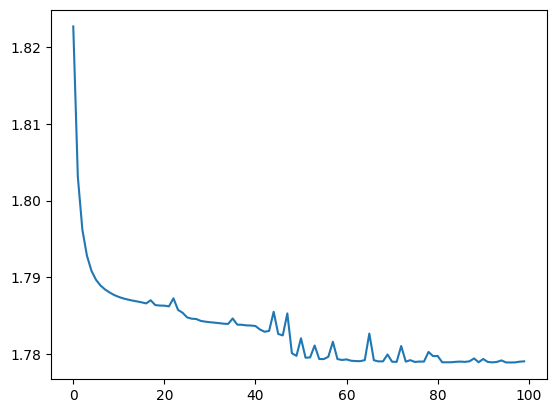

In [11]:

num_bins = 5
num_steps = 10000
lr = 0.1
neural_spline, params, costs = train_neural_spline(xs_torch, num_bins, lr, num_steps, device)
with open("neural_spline_params_test.pkl", "wb") as f:
    pickle.dump((neural_spline, params), f)
plt.plot(costs)
plt.show()

tensor([0.3514, 0.4590, 0.5438, 0.6302], device='cuda:0',
       grad_fn=<SliceBackward0>)


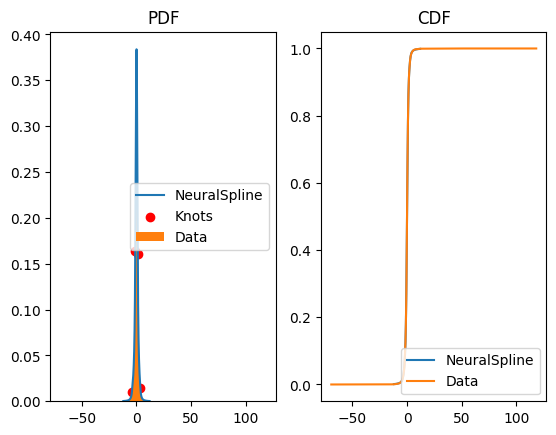

In [13]:
neural_spline, params = pickle.load(open("neural_spline_params_test.pkl", "rb"))
neural_spline = NeuralSpline(num_bins, device)

plot_xs = torch.linspace(-12, 12, 10000)
fig, ax = plt.subplots(1, 2)
ax[0].plot(plot_xs.numpy(), neural_spline.pdf(plot_xs.to(device), *params).cpu().detach().numpy(), label="NeuralSpline")
knots = neural_spline.get_knots(*params)
ax[0].scatter(knots.cpu().detach().numpy(), neural_spline.pdf(knots, *params).cpu().detach().numpy(), color="red", label="Knots")
ax[0].hist(xs, bins=512, density=True, label="Data")
ax[0].legend()
ax[0].set_title("PDF")

ax[1].plot(plot_xs.numpy(), neural_spline.cdf(plot_xs.to(device), *params).cpu().detach().numpy(), label="NeuralSpline")
ax[1].plot(np.sort(xs), np.linspace(0, 1, len(xs)), label="Data")
ax[1].legend()
ax[1].set_title("CDF")
plt.show()
